In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
%matplotlib inline
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import sys
import os
sys.path.append(os.path.abspath('..'))  # adds project root to path

from src.data_cleaning import clean_data

# Set plotting style for a clean, professional look
sns.set_theme(style="whitegrid")

# Load the raw data and apply data cleaning steps

raw_df = pd.read_csv('../data/raw/online_retail_II.csv')
df = clean_data(raw_df)

print(f"Cleaned dataset ready. Shape: {df.shape}")
df.head()

Cleaned dataset ready. Shape: (954730, 13)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,date,year,month,week,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12-01,2009,12,49,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,2009,12,49,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,2009,12,49,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12-01,2009,12,49,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12-01,2009,12,49,30.0


<b>1. Weekly sales volume over time</b>
<br>
Aggregating total units sold across all poducts by week.

<Figure size 1400x600 with 0 Axes>

<Axes: xlabel='year_week', ylabel='Quantity'>

Text(0.5, 1.0, 'Total Weekly Sales Volume (Across All Products)')

Text(0.5, 0, 'Year and ISO Week')

Text(0, 0.5, 'Total Units Sold')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103],
 [Text(0, 0, '2009-W49'),
  Text(1, 0, '2009-W50'),
  Text(2, 0, '2009-W51'),
  Text(3, 0, '2009-W52'),
  Text(4, 0, '2010-W01'),
  Text(5, 0, '2010-W02'),
  Text(6, 0, '2010-W03'),
  Text(7, 0, '2010-W04'),
  Text(8, 0, '2010-W05'),
  Text(9, 0, '2010-W06'),
  Text(10, 0, '2010-W07'),
  Text(11, 0, '2010-W08'),
  Text(12, 0, '2010-W09'),
  Text(13, 0, '2010-W10'),
  Text(14, 0,

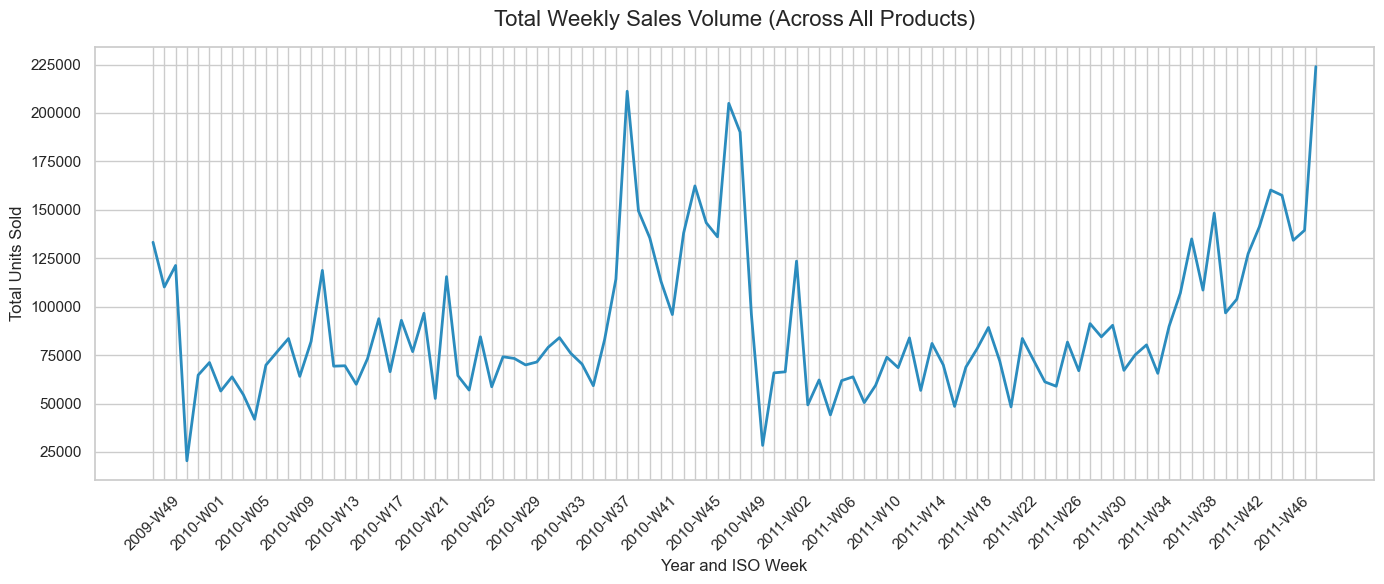

In [38]:
# Aggregate total units sold by year and ISO week
weekly_sales = df.groupby(['year', 'week'])['Quantity'].sum().reset_index()

# Create a readable 'Year-Week' string for the x-axis (e.g., '2010-W45')
weekly_sales['year_week'] = (
    weekly_sales['year'].astype(str) + 
    '-W' + 
    weekly_sales['week'].astype(str).str.zfill(2)
)

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=weekly_sales, x='year_week', y='Quantity', color='#2b8cbe', linewidth=2)

plt.title('Total Weekly Sales Volume (Across All Products)', fontsize=16, pad=15)
plt.xlabel('Year and ISO Week', fontsize=12)
plt.ylabel('Total Units Sold', fontsize=12)

# Rotate and thin out x-axis labels to keep the chart readable
plt.xticks(rotation=45)
ax = plt.gca()
for ind, label in enumerate(ax.get_xticklabels()):
    if ind % 4 == 0:  # Show only every 4th label
        label.set_visible(True)
    else:
        label.set_visible(False)

plt.tight_layout()
plt.show()

This graph shows us that:
<ol>
<li>Most sales are around 50k - 100k units throughout most of the year.
<li>Sales spike around week 35 and end around week 52/week 1 of next year. This is probably due to the <b>Golden Quarter</b> in  retail sales which represents the key holidays/sales events of the year in Q4 leading upto Christmas, such as Black Friday, Boxing Day, etc. Retailers stock products to prepare for the holiday season, which leads to the initial spike around week 35. Units sold drop toward the beginning of the new year, likely due to holiday operational closures.
</ol>
<br>
Now we analyse the price distribution across all product types (SKUs): 

<Axes: xlabel='Price', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of Unit Prices')

Text(0.5, 0, 'Unit Price (£)')

Text(0, 0.5, 'Frequency (Row Count)')

d:\Get a job\Projects\Online Retail UCl\.venv\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='Price'>

Text(0.5, 1.0, 'Box Plot of Unit Prices')

Text(0.5, 0, 'Unit Price (£)')

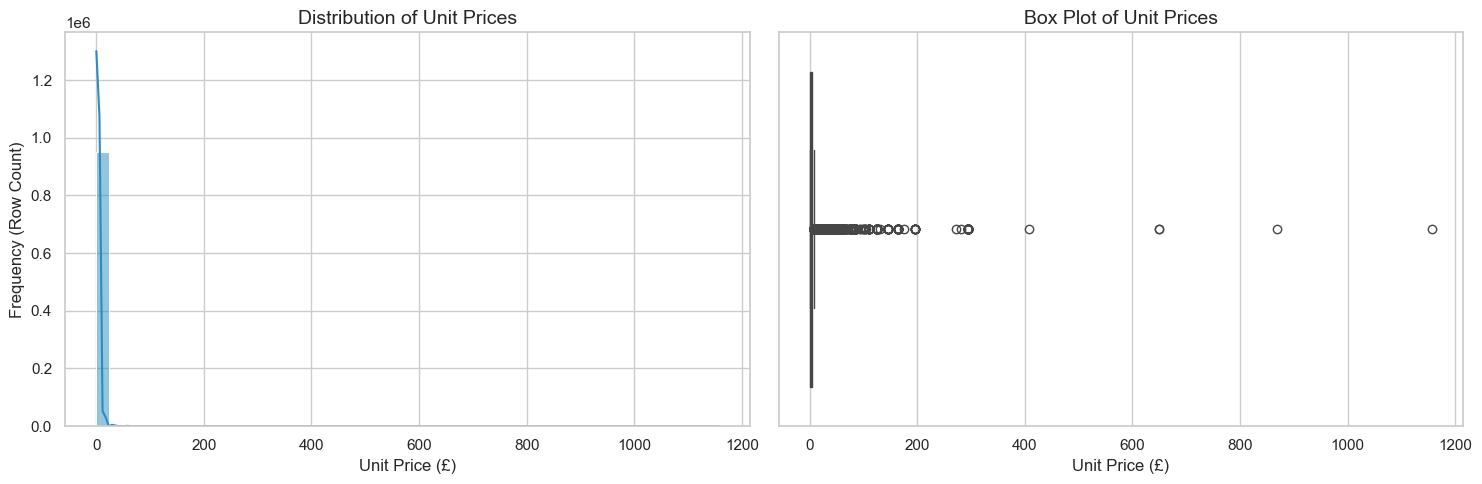

Dataset median price: £2.10
Dataset max price: £1157.15


In [39]:
#price_cap = df['Price'].quantile(0.99)
#plot_data = df[df['Price'] <= price_cap]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
sns.histplot(df['Price'], bins=50, kde=True, ax=axes[0], color='#2b8cbe')
axes[0].set_title('Distribution of Unit Prices', fontsize=14)
axes[0].set_xlabel('Unit Price (£)', fontsize=12)
axes[0].set_ylabel('Frequency (Row Count)', fontsize=12)

# Boxplot
sns.boxplot(x=df['Price'], ax=axes[1], color='#2b8cbe')
axes[1].set_title('Box Plot of Unit Prices', fontsize=14)
axes[1].set_xlabel('Unit Price (£)', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Dataset median price: £{df['Price'].median():.2f}")
print(f"Dataset max price: £{df['Price'].max():.2f}")

We can see the effect of extreme prices on the distribution. Let us take a deeper look by capping at 99th percentile.

<Axes: xlabel='Price', ylabel='Count'>

Text(0.5, 1.0, 'Distribution Capped at 99th Percentile (£16.95)')

Text(0.5, 0, 'Price (£)')

Text(0, 0.5, 'Frequency')

d:\Get a job\Projects\Online Retail UCl\.venv\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


...

Text(0, 0.5, 'Frequency')

d:\Get a job\Projects\Online Retail UCl\.venv\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='Price'>

Text(0.5, 1.0, 'Box Plot (95th Percentile)')

Text(0.5, 0, 'Price (£)')

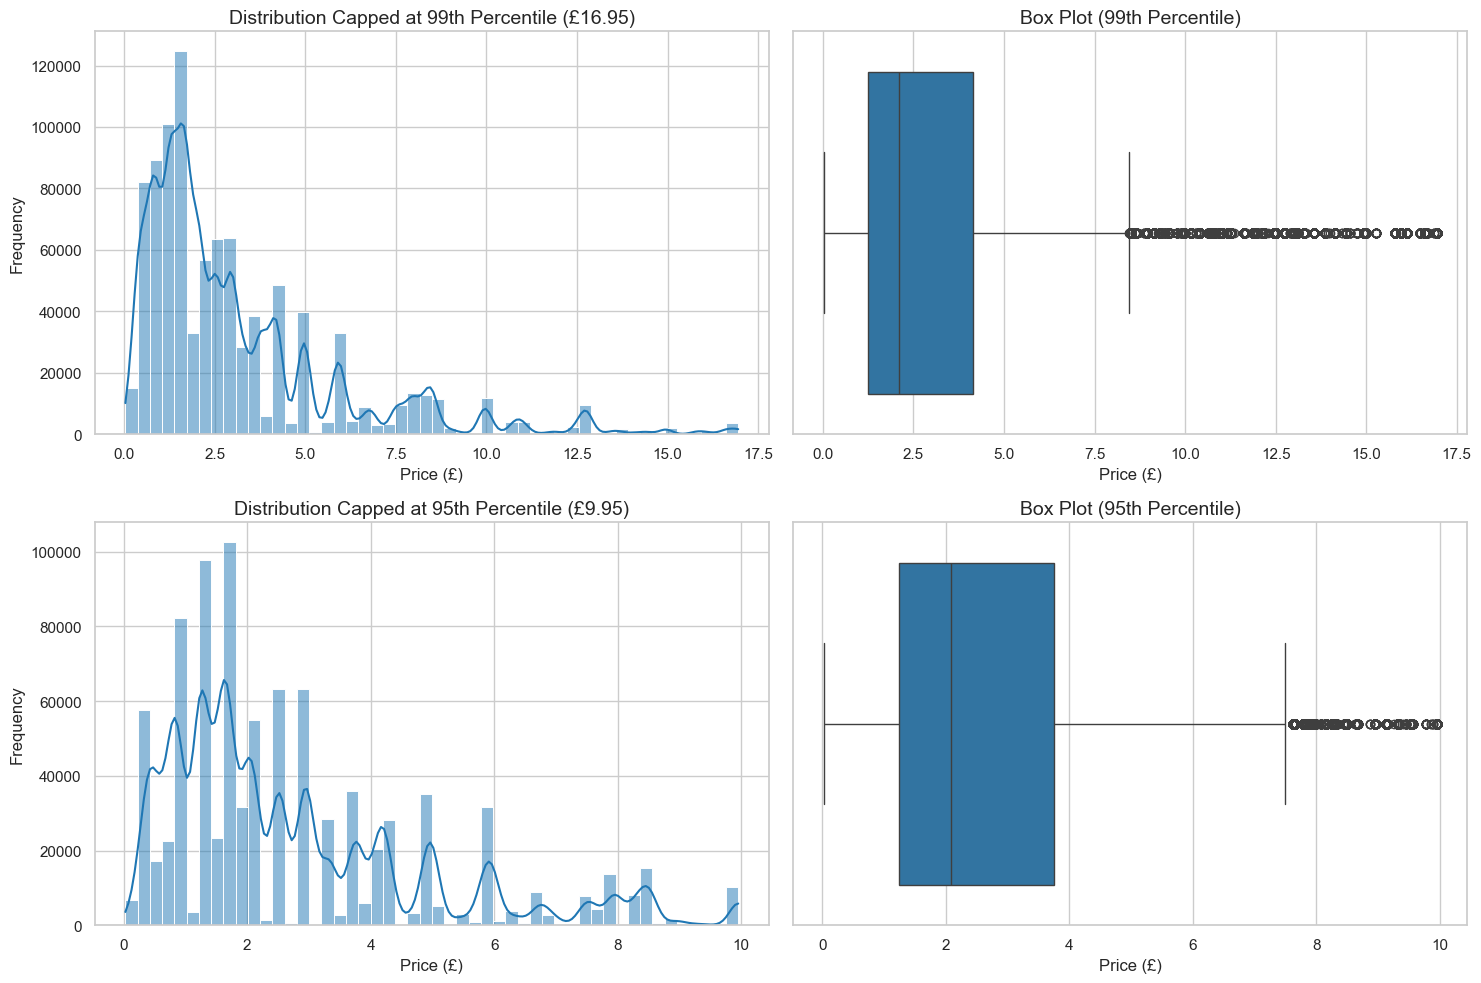

In [40]:
# Calculate the caps
price_cap_99 = df['Price'].quantile(0.99)
price_cap_95 = df['Price'].quantile(0.95)

# Filter the data
plot_data_99 = df[df['Price'] <= price_cap_99]
plot_data_95 = df[df['Price'] <= price_cap_95]

# Set up a 2x2 grid. Increased height from 5 to 10 so the two rows aren't squashed.
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ==========================================
# ROW 1: 99th Percentile
# ==========================================
# Histogram (Top Left)
sns.histplot(plot_data_99['Price'], bins=50, kde=True, ax=axes[0, 0], color='#1f77b4')
axes[0, 0].set_title(f'Distribution Capped at 99th Percentile (£{price_cap_99:.2f})', fontsize=14)
axes[0, 0].set_xlabel('Price (£)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)

# Boxplot (Top Right)
sns.boxplot(x=plot_data_99['Price'], ax=axes[0, 1], color='#1f77b4')
axes[0, 1].set_title('Box Plot (99th Percentile)', fontsize=14)
axes[0, 1].set_xlabel('Price (£)', fontsize=12)

# ==========================================
# ROW 2: 95th Percentile
# ==========================================
# Histogram (Bottom Left)
sns.histplot(plot_data_95['Price'], bins=50, kde=True, ax=axes[1, 0], color='#1f77b4')
axes[1, 0].set_title(f'Distribution Capped at 95th Percentile (£{price_cap_95:.2f})', fontsize=14)
axes[1, 0].set_xlabel('Price (£)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)

# Boxplot (Bottom Right)
sns.boxplot(x=plot_data_95['Price'], ax=axes[1, 1], color='#1f77b4')
axes[1, 1].set_title('Box Plot (95th Percentile)', fontsize=14)
axes[1, 1].set_xlabel('Price (£)', fontsize=12)

plt.tight_layout()
plt.show()

99% of the products sold are under £16.95 while 95% of products are under £9.95.
We need to analyse the top 1% outliers.

<Figure size 1200x500 with 0 Axes>

<Axes: xlabel='Price', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of Prices in the Top 1% (> £16.95)')

Text(0.5, 0, 'Price (£)')

Text(0, 0.5, 'Frequency (Row Count)')

[Text(20, 0, '£20'),
 Text(50, 0, '£50'),
 Text(100, 0, '£100'),
 Text(200, 0, '£200'),
 Text(500, 0, '£500'),
 Text(1000, 0, '£1000'),
 Text(5000, 0, '£5000')]

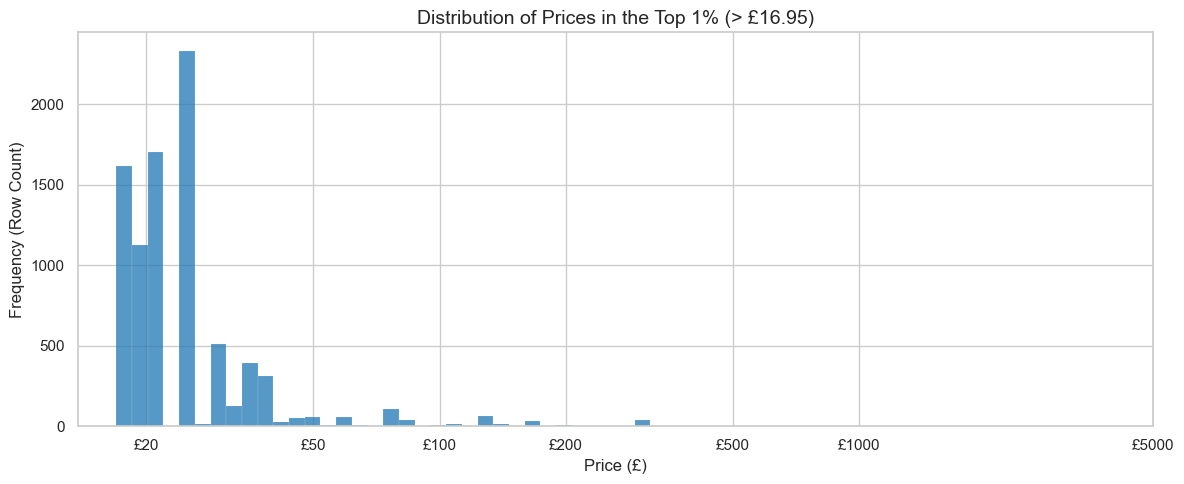

Total unique product-price combinations in the top 1%: 743

Top 15 most frequently sold items in the >99th percentile:


,Description,Price,Transaction_Count
495,REGENCY CAKESTAND 3 TIER,25.49,331
494,REGENCY CAKESTAND 3 TIER,24.96,211
587,SET/4 WHITE RETRO STORAGE CUBES,39.95,167
430,PICNIC BASKET WICKER LARGE,20.79,166
675,VICTORIAN SEWING BOX LARGE,25.49,162
553,SET 3 WICKER LOG BASKETS,19.95,136
197,CREAM SWEETHEART WALL CABINET,18.95,128
253,ENAMEL BREAD BIN CREAM,24.96,108
431,PICNIC BASKET WICKER LARGE,21.23,105
475,RED KITCHEN SCALES,16.98,101


Top 10 Most Expensive Unique Items (with Transaction Counts):


,Description,Price,Transaction_Count
0,FLAG OF ST GEORGE CAR FLAG,1157.15,1
1,PICNIC BASKET WICKER 60 PIECES,649.50,2
2,VINTAGE RED KITCHEN CABINET,295.00,21
3,VINTAGE BLUE KITCHEN CABINET,295.00,19
4,LOVE SEAT ANTIQUE WHITE METAL,195.00,10
5,REGENCY MIRROR WITH SHUTTERS,165.00,6
6,GIANT SEVENTEEN DRAWER SIDEBOARD,165.00,4
7,RUSTIC SEVENTEEN DRAWER SIDEBOARD,165.00,20
8,BLUE KASHMIRI COFFEE TABLE,129.95,1
9,ANT WHITE SWEETHEART TABLE W 3 DRAW,125.00,2


In [44]:
# Isolate the top 1% of transactions based on price
price_cap_99 = df['Price'].quantile(0.99)
top_1_data = df[df['Price'] > price_cap_99]

# 1. Create logarithmically spaced bins
min_val = top_1_data['Price'].min()
max_val = top_1_data['Price'].max()
# np.logspace requires the log10 start and end points
log_bins = np.logspace(np.log10(min_val), np.log10(max_val), 50)

# 2. Plot the distribution using our new log-spaced bins
plt.figure(figsize=(12, 5))
sns.histplot(top_1_data['Price'], bins=log_bins, kde=False, color='#1f77b4')
plt.title(f'Distribution of Prices in the Top 1% (> £{price_cap_99:.2f})', fontsize=14)
plt.xlabel('Price (£)', fontsize=12)
plt.ylabel('Frequency (Row Count)', fontsize=12)

# 3. Apply the log scale to the x-axis
plt.xscale('log')

# 4. Format the x-axis to show actual monetary values instead of scientific notation
ax = plt.gca()
# Define the specific price points we want to label on the axis
custom_ticks = [20, 50, 100, 200, 500, 1000, 5000]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'£{val}' for val in custom_ticks])

# Turn off the minor ticks to keep the axis looking clean
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

plt.tight_layout()
plt.show()

# What are these products? 
top_1_items = (
    top_1_data.groupby(['Description', 'Price'])
    .size()
    .reset_index(name='Transaction_Count')
    .sort_values(by='Transaction_Count', ascending=False)
)

print(f"Total unique product-price combinations in the top 1%: {len(top_1_items)}")
print("\nTop 15 most frequently sold items in the >99th percentile:")
display(top_1_items.head(15))

# Extract the unique descriptions and prices, sort descending, and grab the top 10
top_10_expensive = (
    df.groupby(['Description', 'Price'])
    .size()
    .reset_index(name='Transaction_Count')
    # Sort by price descending to get the most expensive at the top
    .sort_values(by='Price', ascending=False)
    # Drop duplicates just in case the same premium item sold at a slightly lower price too
    .drop_duplicates(subset=['Description'])
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 Most Expensive Unique Items (with Transaction Counts):")
display(top_10_expensive)

The case for `FLAG OF ST GEORGE CAR FLAG` seems interesting, as a flag generally does not cost <b>£1157.15</b>. It might be an error (that may justify why it has only 1 transaction).<br>
Nonetheless, our analysis of the most common and most expensive price points and items seems largely to be within expected behaviour; most products sell under £17 and there are only a few which are over.
<br><br>
To understand how our customers respond to pricing, we plot the weekly demand for every product against its price on a <i>log-log scale</i>.
<br>
To figure out how price affects demand:
<ul><li>We first have to calculate the "weekly demand" for every single product (SKU). We group the data by the product code and the week, add up all the units sold, and find the median price for that week.</li>

<li>Next, we convert both the price and the quantity into their logarithms. We plot all these thousands of data points on a scatterplot and to draw a "line of best fit".</li>
</ul>

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='log_price', ylabel='log_quantity'>

Text(0.5, 1.0, 'Price vs Demand (All Products Pooled)')

Text(0.5, 0, 'Log(Price)')

Text(0, 0.5, 'Log(Weekly Quantity Sold)')

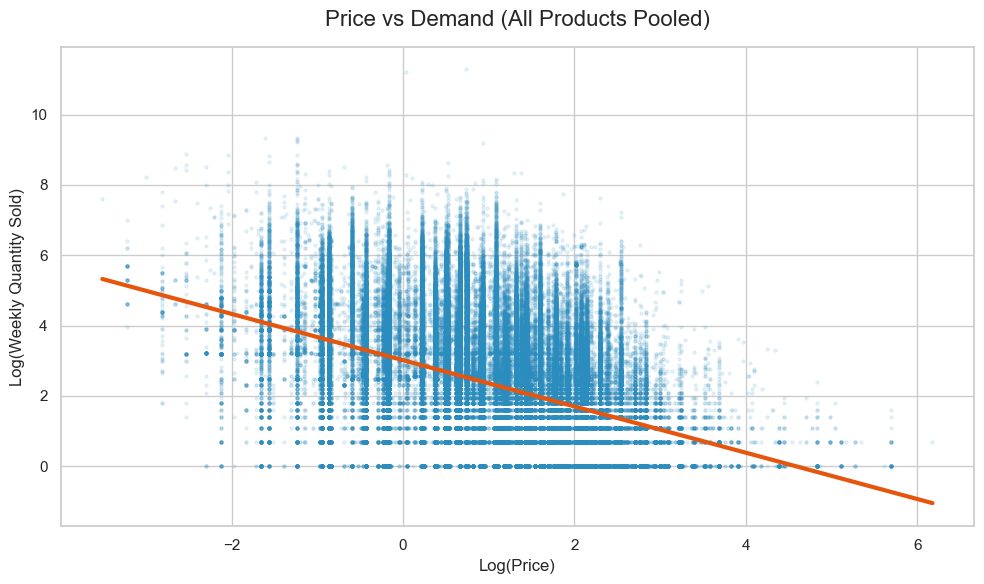

In [ ]:
# 1. Aggregate data weekly at the SKU level
weekly_sku_data = df.groupby(['StockCode', 'year', 'week']).agg(
    weekly_quantity=('Quantity', 'sum'),
    average_price=('Price', 'median')
).reset_index()

# 2. Filter out any zeros to avoid errors when taking the logarithm
weekly_sku_data = weekly_sku_data[
    (weekly_sku_data['weekly_quantity'] > 0) & 
    (weekly_sku_data['average_price'] > 0)
]

# 3. Calculate logarithms for plotting
weekly_sku_data['log_price'] = np.log(weekly_sku_data['average_price'])
weekly_sku_data['log_quantity'] = np.log(weekly_sku_data['weekly_quantity'])

# 4. Generate the scatterplot with a regression trendline
plt.figure(figsize=(10, 6))

sns.regplot(
    data=weekly_sku_data,
    x='log_price',
    y='log_quantity',
    scatter_kws={'alpha': 0.1, 'color': '#2b8cbe', 's': 5},
    line_kws={'color': '#e6550d', 'linewidth': 3}
)

plt.title('Price vs Demand (All Products Pooled)', fontsize=16, pad=15)
plt.xlabel('Log(Price)', fontsize=12)
plt.ylabel('Log(Weekly Quantity Sold)', fontsize=12)

plt.tight_layout()
plt.show()

This plot confirms that the cheaper items sell a lot more in quantity than more expensive items. However this plot does not account for the actual product name/type/category and time of year of sale. Therefore, this plot is not a reliable basis for an elasticity model and markdown optimisation problem. We must categorise products and use temporal features to model elasticity of demand of any product.<br><br>
One last piece of analysis before we proceed to categorise the products. We need to see a sample of how different types of products sell over the course of a year.<br>
Lets take 5 random SKUs from a sample of the top 150 selling SKUs. Lets plot their cumulative sales over a 12 week "season" starting from weeks 35 - 46 in 2010.

<i>Instead of taking the whole dataset, we first slice the data to only look at Autumn 2010 (Weeks 35 to 46). This acts as a controlled environment where all products in this slice are experiencing the exact same seasonal trends and holiday buildup.
We find the top 50 best-selling items during that specific time, pick 5 at random, and plot how fast they accumulated sales over those 12 weeks. Because the timeframe is identical for every line on the chart, any differences in the slopes are purely down to the products themselves, not the time of year.</i>

<Figure size 1200x600 with 0 Axes>

d:\Get a job\Projects\Online Retail UCl\.venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
d:\Get a job\Projects\Online Retail UCl\.venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
d:\Get a job\Projects\Online Retail UCl\.venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
d:\Get a j

<Axes: xlabel='week', ylabel='cumulative_sold'>

Text(0.5, 1.0, '12-Week Sell-Through Trajectory (Weeks 35-46, 2010)')

Text(0.5, 0, 'ISO Week Number')

Text(0, 0.5, 'Cumulative Units Sold')

([<matplotlib.axis.XTick at 0x1315467dc10>,
 [Text(35, 0, '35'),
  Text(36, 0, '36'),
  Text(37, 0, '37'),
  Text(38, 0, '38'),
  Text(39, 0, '39'),
  Text(40, 0, '40'),
  Text(41, 0, '41'),
  Text(42, 0, '42'),
  Text(43, 0, '43'),
  Text(44, 0, '44'),
  Text(45, 0, '45'),
  Text(46, 0, '46')])

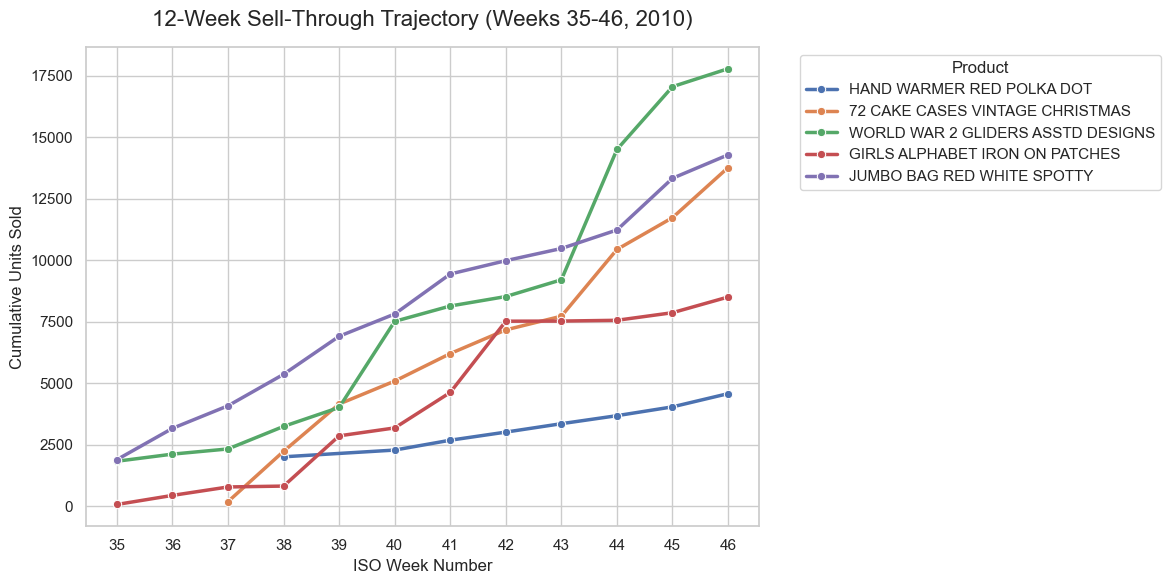

In [50]:
import random

# 1. Define our fixed 12-week calendar window to control for seasonality
target_year = 2010
start_week = 35
end_week = 46

window_data = df[
    (df['year'] == target_year) & 
    (df['week'] >= start_week) & 
    (df['week'] <= end_week)
]

# 2. Identify top SKUs specifically within this time window to ensure they were active
top_window_skus = window_data.groupby('StockCode')['Quantity'].sum().nlargest(50).index.tolist()

# 3. Randomly sample 5 SKUs from this active pool
random.seed(69)
sample_skus = random.sample(top_window_skus, 5)

# 4. Filter data for these 5 SKUs and aggregate weekly
sample_data = window_data[window_data['StockCode'].isin(sample_skus)].copy()
weekly_sample = sample_data.groupby(['StockCode', 'week']).agg(
    weekly_quantity=('Quantity', 'sum')
).reset_index()

# 5. Calculate cumulative sales
# Sort to ensure chronological order before calculating cumulative sums
weekly_sample = weekly_sample.sort_values(by=['StockCode', 'week'])

# Calculate running total of units sold per SKU
weekly_sample['cumulative_sold'] = weekly_sample.groupby('StockCode')['weekly_quantity'].cumsum()

# 6. Map the StockCodes back to readable product descriptions
sku_to_desc = df[['StockCode', 'Description']].drop_duplicates(subset=['StockCode']).set_index('StockCode')['Description'].to_dict()
weekly_sample['Product_Name'] = weekly_sample['StockCode'].map(sku_to_desc)

# 7. Generate the plot
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=weekly_sample, 
    x='week', 
    y='cumulative_sold', 
    hue='Product_Name', 
    marker='o', 
    linewidth=2.5
)

plt.title(f'12-Week Sell-Through Trajectory (Weeks {start_week}-{end_week}, {target_year})', fontsize=16, pad=15)
plt.xlabel('ISO Week Number', fontsize=12)
plt.ylabel('Cumulative Units Sold', fontsize=12)

# Ensure all 12 weeks show on the x-axis
plt.xticks(range(start_week, end_week + 1))

# Move the legend outside the plot
plt.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


This chart proves that time of year alone is not enough to model sell-through speed. Different products deplete their inventory at different rates (even though time of year may predict a general, overall trend for sales quantity).

Summarising the findings from this notebook:
<ol>
<li>Demand is highly seasonal.

<li>Product prices are heterogeneous.

<li>Sell-through rates vary wildly, even under the exact same conditions.
</ol>